In [155]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import xarray as xr
import os
import matplotlib as mpl
fs=10
mpl.rc('xtick', labelsize=fs)
mpl.rc('ytick', labelsize=fs)
mpl.rc('legend', fontsize=fs)
mpl.rc('axes', titlesize=fs)
mpl.rc('axes', labelsize=fs)
mpl.rc('figure', titlesize=fs)
mpl.rc('font', size=fs)
mpl.rc('font', family='sans-serif', weight='normal', style='normal')



In [156]:
# mask = xr.open_dataset('/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc')
# coords=  xr.open_dataset('~/MOAD/grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)

In [157]:
runs = ['Diatpref','Exchbac','Exchbac_2','Growthflag','Growthflag_2','Mortbac','Predflag','Remin']

In [158]:
jjii = xr.open_dataset('~/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [159]:
pdf = pd.read_csv('parameters.csv')
for run in runs:
   pdf[run] = pdf[run]/pdf['Base']
pdf

,Parameter,Base,Diatpref,Exchbac,Exchbac_2,Growthflag,Growthflag_2,Mortbac,Predflag,Remin
0,zz_rate_uzoo_diatPref,2.600000e-01,0.653846,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
1,zz_rate_mesozoo_diatPref,3.475000e-01,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.107914,1.000000
2,zz_rate_uzoo_hbacPref,1.700000e-01,1.529412,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
3,zz_rate_HBac_excr,1.450000e-06,1.000000,1.103448,2.62069,1.000000,1.000000,1.000000,1.000000,2.758621
4,zz_rate_R_flag,1.800000e-05,1.000000,1.000000,1.00000,1.111111,1.555556,1.000000,1.000000,1.000000
5,zz_rate_HBac_Rm,3.500000e-07,1.000000,1.000000,1.00000,1.000000,1.000000,1.114286,1.000000,1.000000
6,zz_rate_mesozoo_flagPref,1.220000e-01,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,0.000000,1.000000
7,zz_rate_mesozoo_PON_Pref,1.830000e-01,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.256831,1.000000
8,zz_rate_mesozoo_Z_Pref,3.475000e-01,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.107914,1.000000
9,zz_rate_HBac_NO3HalfSat,1.000000e+00,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,0.100000


In [160]:
runs2 = ['Diatpref','Exchbac','Exchbac_2','Growthflag','Growthflag_2','Mortbac','Predflag','Remin','Base']
evdf = pd.read_csv('evaluation.csv',index_col=0)
for run in runs2:
    evdf.loc[run,'NO3(RMSE)']= evdf.loc[run,'NO3(RMSE)']/evdf.loc['Base','NO3(RMSE)']
    evdf.loc[run,'DO(RMSE)']= evdf.loc[run,'DO(RMSE)']/evdf.loc['Base','DO(RMSE)']
evdf

,NO3(RMSE),NO3(Bias),PP_diff,BP/PP,DO(RMSE),DO(Bias)
Base,1.000000,-1.450000,-0.200703,1.62,1.000000,-3.66
Diatpref,1.042907,-2.099902,-0.181544,0.67,1.031791,-0.18
Exchbac,0.999764,-1.280854,-0.207649,1.58,1.011331,-3.26
Exchbac_2,0.981919,-1.350141,-0.208542,0.46,1.016682,-3.53
Growthflag,1.002301,-1.361329,-0.260497,1.73,0.999370,-3.62
Growthflag_2,1.060113,-1.567768,-0.126525,1.36,1.022033,-4.05
Mortbac,0.985133,-1.400217,-0.244534,1.66,0.995908,-3.59
Predflag,1.029462,-1.344575,-0.191125,1.47,1.012276,-3.77
Remin,1.026726,-1.123124,-0.190148,0.38,1.017941,-3.27


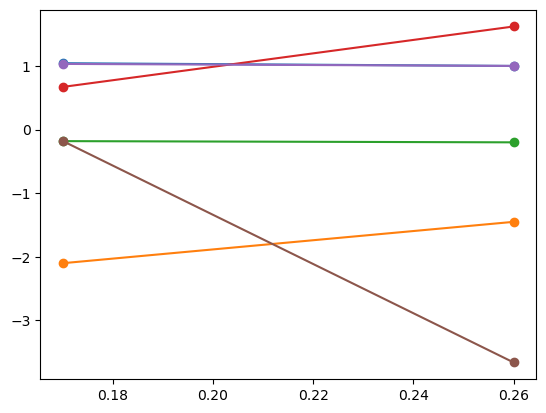

In [161]:
params = pdf.Parameter
par = pdf[(pdf['Parameter']==params[0])]
par = par.loc[:, ~(par == 1).all()]
parlist = []
evallist = []
for run in par.columns[1:]:
   if run != 'Base':
       parlist.append(par[run] * par['Base'])
   else:
       parlist.append(par[run])
   evallist.append(evdf.loc[run].values)
a = plt.plot(parlist,evallist,'o-')


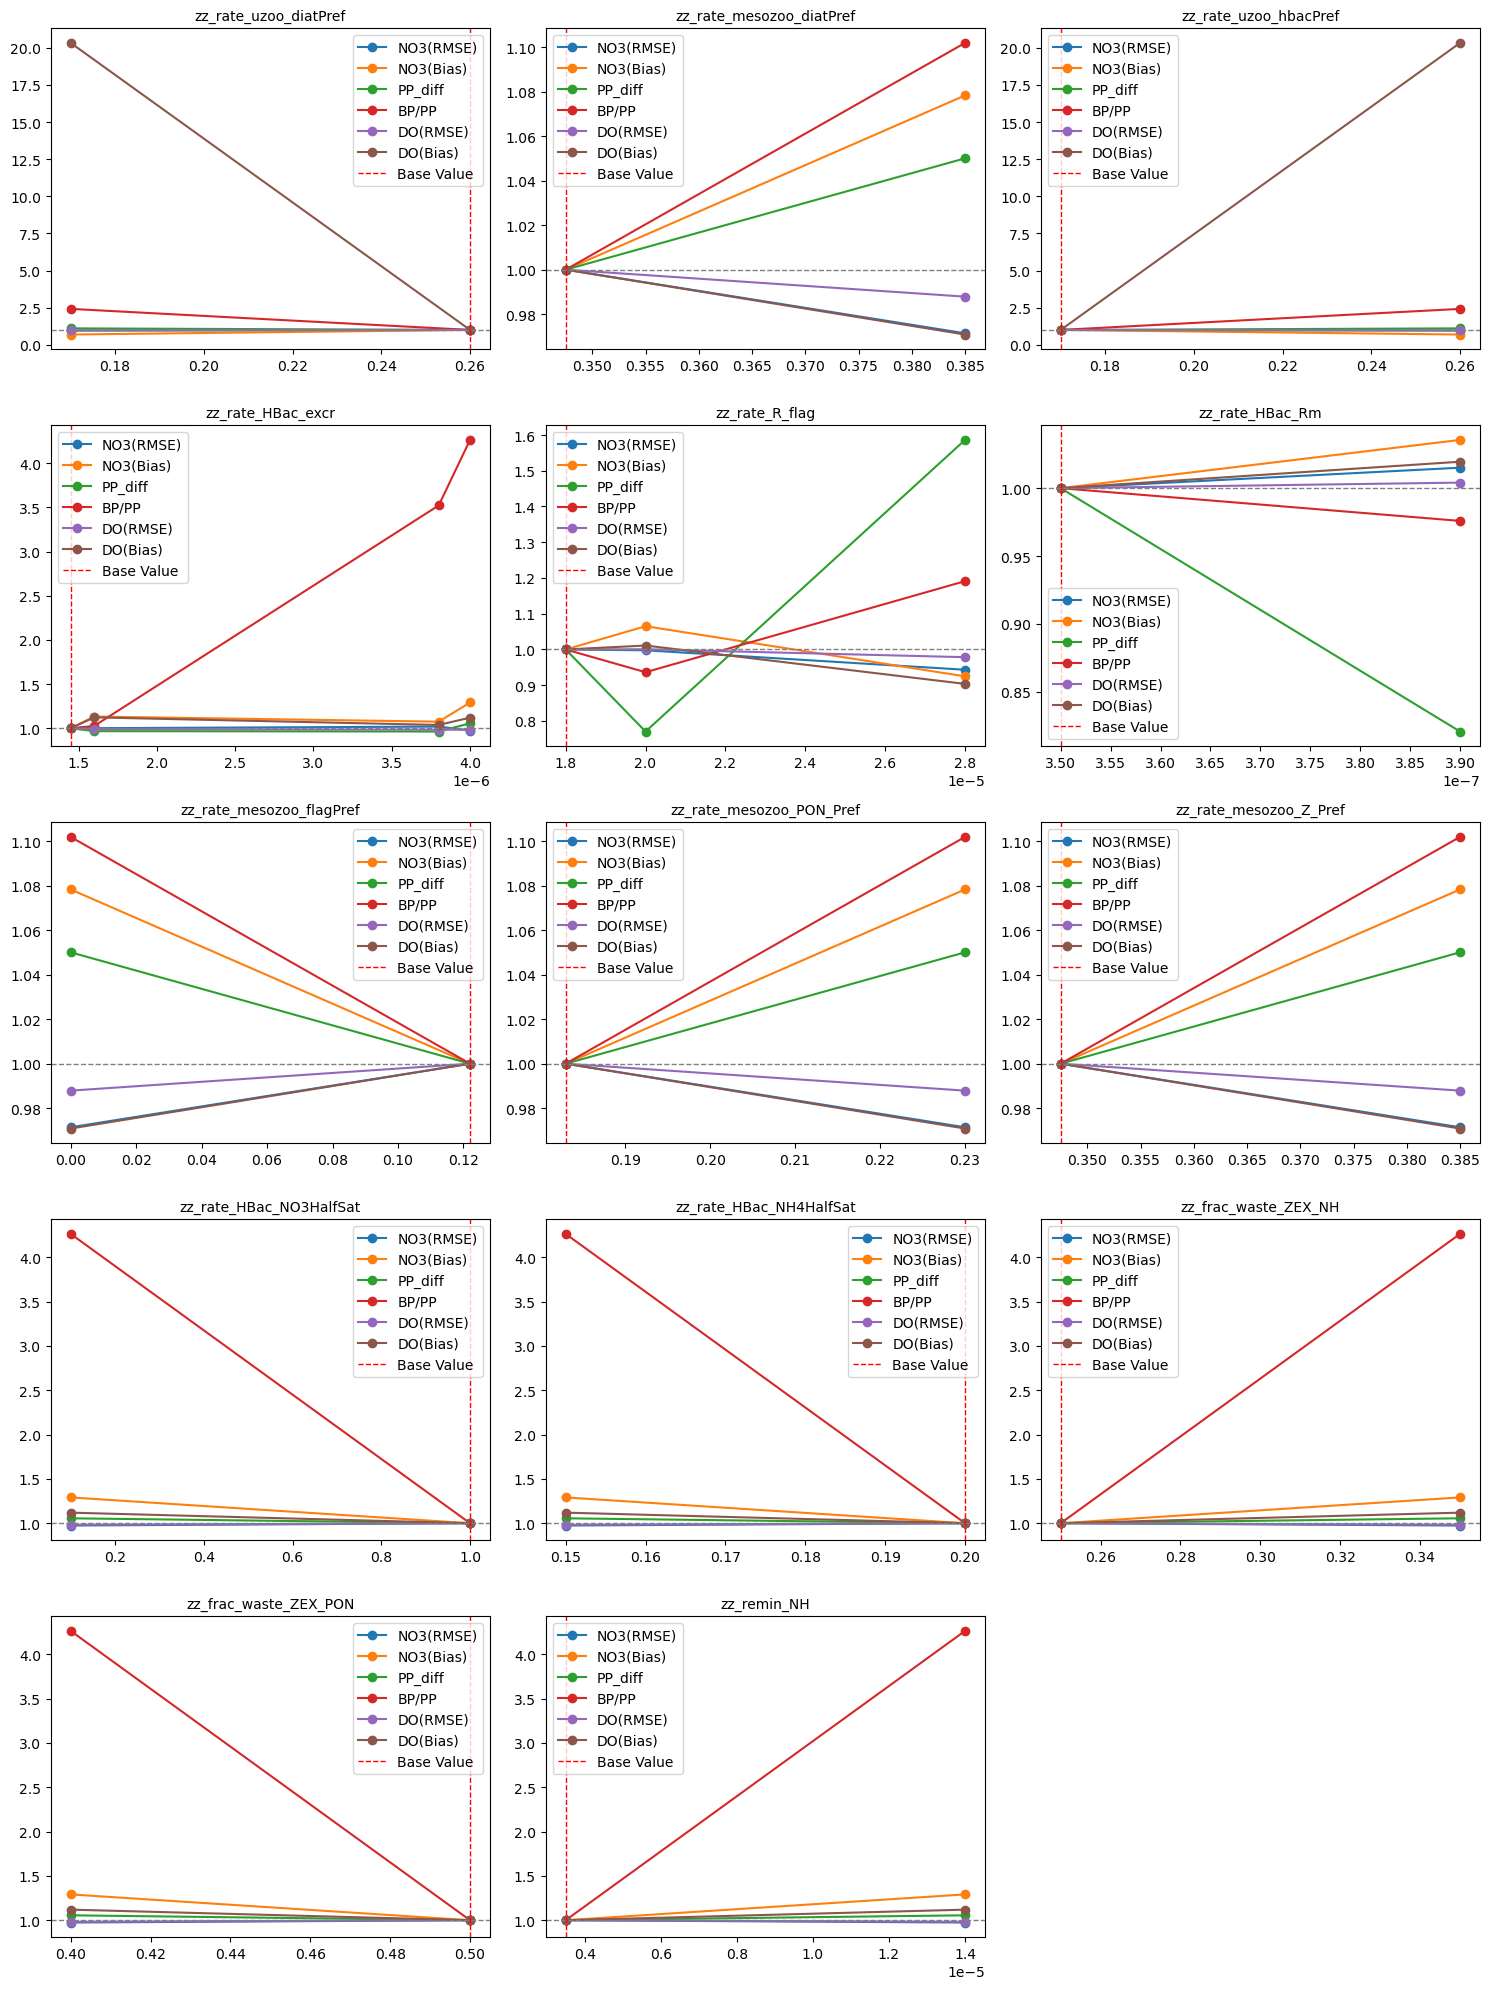

In [162]:
import matplotlib.pyplot as plt
import numpy as np

params = pdf['Parameter'].unique()

n = len(params)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axs = axs.flatten()

for i, param in enumerate(params):
    ax = axs[i]
    
    # Filter rows for this parameter
    par = pdf.loc[pdf['Parameter'] == param]
    
    # Ensure Base exists
    base = par['Base'] if 'Base' in par.columns else 1
    
    parlist = []
    evallist = []
    
    for run in par.columns[1:]:
        # Skip columns that are all 1 (except Base)
        if run != 'Base' and (par[run] == 1).all():
            continue
        
        # Build x values
        x = (par[run] * base).values if run != 'Base' else par[run].values
        parlist.append(x)
        
        # Get evaluation values
        evallist.append(evdf.loc[run].values.astype(float))
    
    parlist = np.array(parlist).squeeze()
    evallist = np.array(evallist)
    
    # -------------------------------
    # Normalize all error metrics so lower is better
    # -------------------------------
    if 'Base' in evdf.index:
        base_vals = evdf.loc['Base'].values.astype(float)
        
        for j, col in enumerate(evdf.columns):
            y = evallist[:, j]
            b = base_vals[j]
            
            # For bias metrics, use absolute values
            if 'bias' in col.lower():
                y = np.abs(y)
                b = np.abs(b)
            
            # Lower is better → invert ratio
            evallist[:, j] = b / (y + 1e-12)
    
    # Plot each metric
    for j, col in enumerate(evdf.columns):
        ax.plot(parlist, evallist[:, j], 'o-', label=col)
        #ax.set_ylim(0.5,1.5)
    
    ax.set_title(param)
    ax.axhline(1, linestyle='--', linewidth=1, color='gray')  # baseline reference
    
    # -------------------------------
    # Add vertical line at Base value
    # -------------------------------
    base_x = base.values[0] if hasattr(base, 'values') else base
    ax.axvline(base_x, linestyle='--', linewidth=1, color='red', label='Base Value')
    
    ax.legend()

# Remove unused axes
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()